# ATO 2021-22 postcode data cleaning results

This report reads and verifies the saved cleaning results live, showing the processing rules,
coverage, quality, and usage limits. Each row is a postcode. Regional tax statistics are not an
individual's purchasing power or credit risk.
Full transaction integration and merchant scoring were not done here.


In [1]:
from pathlib import Path
import json
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd()
module = next(p for p in [cwd, cwd.parent, cwd / 'external_ato'] if (p / 'results/metadata.json').exists())
results = module / 'results'
meta = json.loads((results / 'metadata.json').read_text())
df = pd.read_parquet(results / 'ato_clean.parquet')
csv_df = pd.read_csv(results / 'ato_clean.csv', dtype={'postcode': 'string'})
pd.testing.assert_frame_equal(df, csv_df, check_dtype=False)
assert df.postcode.is_unique and df.postcode.str.fullmatch(r'[0-9]{4}').all()
assert '0800' in set(df.postcode)
display(pd.DataFrame([{'raw_rows':meta['source_data_rows'], 'clean_rows':len(df), 'columns':len(df.columns),
                       'excluded_rows':meta['excluded_rows'], 'quality_issues':meta['quality_issue_cells']}]))
display(df.head())


,raw_rows,clean_rows,columns,excluded_rows,quality_issues
0,2639,2630,21,9,0


,postcode,ato_income_year,ato_state,ato_sa4_name,ato_sa4_is_state_other,ato_individual_count,ato_taxable_income_reporter_count,ato_taxable_income_or_loss_total,ato_salary_recipient_count,ato_salary_or_wages_total,...,ato_net_tax_total,ato_taxable_income_or_loss_per_reporter,ato_salary_or_wages_per_recipient,ato_salary_recipient_share,ato_net_tax_payer_share,ato_min_derived_denominator,ato_small_denominator,ato_nonpositive_taxable_income_total,ato_any_feature_missing,ato_quality_issue
0,0800,2021-22,NT,Darwin,False,5430,5369,4.005201e+08,4914,3.609490e+08,...,88088853.0,74598.635500,73453.197599,0.904972,0.844015,4914,False,False,False,False
1,0801,2021-22,NT,NT other,True,408,402,3.732662e+07,312,2.529114e+07,...,9644586.0,92852.298507,81061.339744,0.764706,0.818627,312,False,False,False,False
2,0804,2021-22,NT,NT other,True,81,79,7.873653e+06,64,6.292514e+06,...,1971041.0,99666.493671,98320.531250,0.790123,0.888889,64,True,False,False,False
3,0810,2021-22,NT,Darwin,False,22405,22221,1.685072e+09,19685,1.485710e+09,...,374302719.0,75832.394087,75474.234290,0.878599,0.824548,19685,False,False,False,False
4,0811,2021-22,NT,NT other,True,157,156,1.443222e+07,116,1.058100e+07,...,3702496.0,92514.243590,91215.560345,0.738854,0.847134,116,False,False,False,False


## 1. Cleaning and reconciliation

Only the full individual records from Table 6B are used; Table 6A's two tax-status sub-groups are
used to reconcile against them, not added in again. Postcodes are normalised, state "other" and
Overseas aggregate records are isolated, and unique keys, values, ratios, and denominators are
checked. Genuine zero values and negative income are kept -- no imputation, winsorising, or removal
of statistical outliers. The exact cause of a state-"other" record can't be determined from the
label alone. The pipeline stops if a reconciliation key or value doesn't match.


In [2]:
excluded = pd.read_csv(results / 'excluded_records.csv')
reconciliation = pd.read_csv(results / 'table6a_reconciliation.csv')
assert reconciliation[['records_only_in_6a','records_only_in_6b','records_beyond_tolerance']].to_numpy().sum() == 0
display(excluded)
display(reconciliation)
display(pd.read_csv(results / 'feature_quality_profile.csv'))


,excel_row,source_postcode,source_state,reason,individual_count,taxable_income_or_loss_total
0,29,ACT other,ACT,state_other_aggregate,191,17448826
1,655,NSW other,NSW,state_other_aggregate,3390,352021518
2,700,NT other,NT,state_other_aggregate,154,10979731
3,701,Overseas,Overseas,overseas_aggregate,123657,3888397917
4,1136,QLD other,QLD,state_other_aggregate,1740,119192037
5,1467,SA other,SA,state_other_aggregate,681,46739456
6,1582,TAS other,TAS,state_other_aggregate,216,12737134
7,2283,VIC other,VIC,state_other_aggregate,1901,135885138
8,2641,WA other,WA,state_other_aggregate,3223,285196601


,field,records_compared,records_only_in_6a,records_only_in_6b,records_beyond_tolerance,max_abs_difference,tolerance
0,ato_individual_count,2639,0,0,0,0,0
1,ato_taxable_income_reporter_count,2639,0,0,0,0,0
2,ato_taxable_income_or_loss_total,2639,0,0,0,0,2
3,ato_salary_recipient_count,2639,0,0,0,0,0
4,ato_salary_or_wages_total,2639,0,0,0,0,2
5,ato_net_tax_count,2639,0,0,0,0,0
6,ato_net_tax_total,2639,0,0,0,0,2


,field,rows,missing,minimum,maximum,zero_count,negative_count
0,ato_individual_count,2630,0,5.100000e+01,8.012100e+04,0,0
1,ato_taxable_income_reporter_count,2630,0,4.500000e+01,7.862700e+04,0,0
2,ato_taxable_income_or_loss_total,2630,0,1.368192e+06,5.074196e+09,0,0
3,ato_salary_recipient_count,2630,0,1.900000e+01,6.735000e+04,0,0
4,ato_salary_or_wages_total,2630,0,9.034130e+05,4.403558e+09,0,0
5,ato_net_tax_count,2630,0,1.900000e+01,6.066200e+04,0,0
6,ato_net_tax_total,2630,0,2.055860e+05,1.541281e+09,0,0
7,ato_taxable_income_or_loss_per_reporter,2630,0,2.096724e+04,3.596421e+05,0,0
8,ato_salary_or_wages_per_recipient,2630,0,1.779796e+04,1.594454e+05,0,0
9,ato_salary_recipient_share,2630,0,2.000000e-01,9.965157e-01,0,0


## 2. Consumer postcode coverage

Coverage rates use the project's provided synthetic consumer records as the denominator -- this is
not Australia's population coverage, nor transaction/transaction-amount coverage. Combined coverage
only means the postcode exists in all three tables; it doesn't guarantee every Census/SEIFA metric
has a value. A state mismatch is only logged for audit, not treated as proof the consumer's record
is wrong. The number-range label is a heuristic and doesn't prove the reason for a non-match.


,scope,metric,rows,denominator,rate
0,consumer_rows,matched,414825,499999,0.829652
1,consumer_rows,postcode_not_in_ato,85174,499999,0.170348
2,consumer_rows,missing_or_invalid_postcode,0,499999,0.000000
3,distinct_valid_postcodes,matched,2627,3167,0.829492
4,distinct_valid_postcodes,postcode_not_in_ato,540,3167,0.170508
5,consumer_rows,matched_but_consumer_state_differs_from_ato_state,889,499999,0.001778
6,consumer_rows,postcode_in_ato_and_census,404185,499999,0.808372
7,consumer_rows,postcode_in_ato_and_seifa,404185,499999,0.808372
8,consumer_rows,postcode_in_all_sources,404185,499999,0.808372


,consumer_state,ato_state,consumer_rows
0,ACT,NSW,281
1,NSW,ACT,149
2,NSW,QLD,300
3,NSW,VIC,159


,field,available_consumer_rows,missing_consumer_rows,total_consumer_rows
0,ato_individual_count,414825,85174,499999
1,ato_taxable_income_reporter_count,414825,85174,499999
2,ato_taxable_income_or_loss_total,414825,85174,499999
3,ato_salary_recipient_count,414825,85174,499999
4,ato_salary_or_wages_total,414825,85174,499999
5,ato_net_tax_count,414825,85174,499999
6,ato_net_tax_total,414825,85174,499999
7,ato_taxable_income_or_loss_per_reporter,414825,85174,499999
8,ato_salary_or_wages_per_recipient,414825,85174,499999
9,ato_salary_recipient_share,414825,85174,499999


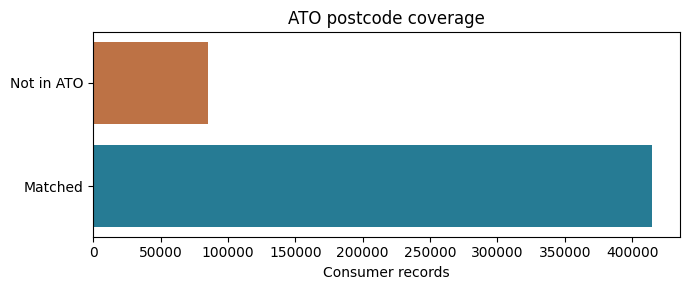

In [3]:
coverage = pd.read_csv(results / 'consumer_join_coverage.csv')
display(coverage)
display(pd.read_csv(results / 'consumer_state_consistency.csv'))
display(pd.read_csv(results / 'consumer_feature_missingness.csv'))
base = coverage[(coverage.scope == 'consumer_rows') & coverage.metric.isin(['matched','postcode_not_in_ato'])]
fig, ax = plt.subplots(figsize=(7,3))
ax.barh(['Matched','Not in ATO'], [base.loc[base.metric.eq(k),'rows'].iloc[0] for k in ['matched','postcode_not_in_ato']], color=['#267b94','#bd7245'])
ax.set_xlabel('Consumer records'); ax.set_title('ATO postcode coverage')
fig.tight_layout()
(module / 'curation_summary/figures').mkdir(exist_ok=True)
fig.savefig(module / 'curation_summary/figures/consumer_coverage.png', dpi=150)
plt.show()


## 3. Regional metrics and quality flags

Taxable-income amounts are divided by their corresponding reporter-count label; salary amounts are
divided by the salary-recipient count. These are means, not medians. Salary-recipient share is not
an employment rate, and net-tax-payer share is not a compliance or fraud indicator. A derived-metric
denominator below 100 is this project's own review threshold, not an official suppression rule, and
no postcode is removed for it.


,field,source_or_formula,unit,definition
0,ato_individual_count,Individuals no.,count,All individuals in this Table 6B area record
1,ato_taxable_income_reporter_count,Taxable income or loss4 no.,count,Count for the taxable income or loss label; no...
2,ato_taxable_income_or_loss_total,Taxable income or loss4 $,AUD/year,Published total taxable income or loss
3,ato_salary_recipient_count,Salary or wages no.,count,Count for salary or wages label
4,ato_salary_or_wages_total,Salary or wages $,AUD/year,Published total salary or wages
5,ato_net_tax_count,Net tax no.,count,Count for net tax label; not a fraud or defaul...
6,ato_net_tax_total,Net tax $,AUD/year,Published net tax amount
7,ato_taxable_income_or_loss_per_reporter,ato_taxable_income_or_loss_total / ato_taxable...,AUD/year,Derived total divided by corresponding label c...
8,ato_salary_or_wages_per_recipient,ato_salary_or_wages_total / ato_salary_recipie...,AUD/year,Derived salary total divided by salary recipie...
9,ato_salary_recipient_share,ato_salary_recipient_count / ato_individual_count,proportion 0-1,Salary recipients divided by all individuals; ...


,flag,postcodes
0,small denominator,255
1,SA4 state-other placeholder,69


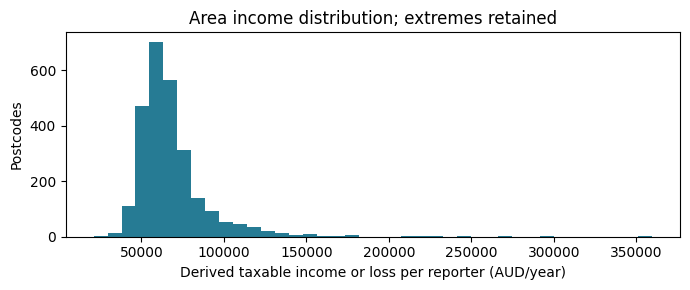

In [4]:
display(pd.read_csv(results / 'data_dictionary.csv'))
display(pd.DataFrame({'flag':['small denominator','SA4 state-other placeholder'],
                      'postcodes':[df.ato_small_denominator.sum(),df.ato_sa4_is_state_other.sum()]}))
fig, ax = plt.subplots(figsize=(7,3))
ax.hist(df.ato_taxable_income_or_loss_per_reporter, bins=40, color='#267b94')
ax.set_xlabel('Derived taxable income or loss per reporter (AUD/year)')
ax.set_ylabel('Postcodes'); ax.set_title('Area income distribution; extremes retained')
fig.tight_layout(); fig.savefig(module / 'curation_summary/figures/income_distribution.png', dpi=150)
plt.show()


## 4. Official median candidate table

Separately verified against Individuals Table 8, keeping the official 2021-22 mean and median.
Its Notes state that only postcodes with more than 200 returns are published for that year;
unpublished values are kept as missing `na`. The official Notes define their own statistical basis
for the mean/median. The median can't be inferred from Table 6B's totals, and the two tables' means
shouldn't be assumed identical either. This candidate table is only kept here, not merged to replace
the existing features.


In [5]:
median = pd.read_parquet(module / 'median_reference/ato_table8_candidates.parquet')
median_meta = json.loads((module / 'median_reference/metadata.json').read_text())
display(pd.DataFrame([{'postcodes_in_table8':len(median), 'available_2021_22':median.ato_table8_available.sum(),
                       'unavailable_2021_22':(~median.ato_table8_available).sum()}]))
display(median.head())
print(median_meta['source_url'])


,postcodes_in_table8,available_2021_22,unavailable_2021_22
0,2317,2270,47


,postcode,ato_income_year,ato_table8_state,ato_table8_individual_count,ato_official_median_taxable_income,ato_official_average_taxable_income,ato_table8_available
0,0800,2021-22,NT,5430.0,62290.0,73761.0,True
1,0801,2021-22,NT,408.0,67876.0,91487.0,True
2,0804,2021-22,NT,NaN,NaN,NaN,False
3,0810,2021-22,NT,22405.0,64580.0,75210.0,True
4,0811,2021-22,NT,NaN,NaN,NaN,False


https://data.gov.au/data/dataset/4be150cc-8f84-46b8-8c61-55ff1d48a700/resource/9bd9d5af-2c09-405f-b484-69c862f4dc2e/download/ts22individual08medianaveragetaxableincomestatepostcode.xlsx


## 5. Usage boundaries and next steps

This is the 2021-22 income year, as processed up to 2023-10-31 -- it should not be treated as a
predictive input known at the time a transaction occurred. ATO postcodes are not identical to ABS
POAs. Missingness must not simply be zero-filled, and regional metrics must not be interpreted as
facts about an individual. Next, join by consumer postcode, check that row counts and merchant
coverage are unchanged, then decide whether to use the mean or the official median.
Full transaction integration, merchant-feature construction, fraud analysis, and ranking have not
been done yet.


In [6]:
print('Source:', meta['source_url'])
print('Workbook SHA-256:', meta['source_sha256'])
print('Data processing cutoff:', meta['source_processing_cutoff'])
print('Parquet postcode type:', pq.read_schema(results / 'ato_clean.parquet').field('postcode').type)


Source: https://data.gov.au/data/dataset/5fa69f19-ec44-4c46-88eb-0f6fd5c2f43b/resource/00847743-8b5b-4d41-a15a-1a28cf00ea81/download/ts22individual06taxablestatusstatesa4postcode.xlsx
Workbook SHA-256: 00d1df972edc02af9d61d9968d586c7292dc7785f75e35242699af4ad3833b3d
Data processing cutoff: 2023-10-31
Parquet postcode type: string
